![Loan approval risk modeling banner](images/banner.png)

# Smarter Lending: Predicting Loan Default Risk to Reduce Credit Losses at FinTech Innovations

# Overview

Bottom Line Up Front: A cost-sensitive logistic regression model can screen FinTech Innovations' loan applications with a 0.97 ROC-AUC and 96% precision on approvals. On 4,000 held-out applicants, it reduced the total cost of lending errors to $4.51 million, 41% less than denying all applicants and 97% less than approving all of them, a saving of about $3.1 million. Because a defaulted loan costs about $50,000, more than six times the $8,000 profit lost by denying a good applicant, the model is deliberately cautious: it approves about 55% of creditworthy applicants in exchange for making very few costly bad approvals. Total debt-to-income ratio and annual income are by far the strongest predictors, making this primarily an affordability model. Before deployment, the approval gaps across age groups and income levels require fair-lending review. We recommend using the model as a decision-support tool, auto-approving low-risk applicants, flagging high-risk ones, and routing borderline cases to loan officers, with ongoing monitoring for drift and fairness.

1. FinTech Innovations currently relies on loan officers to manually review each application. This process is slow, which limits volume and delays decisions; inconsistent, since different officers may judge similar applicants differently; vulnerable to bias, which creates fairness and regulatory risk; and limited in its ability to spot complex patterns across many financial and behavioral variables. Every mistake is expensive.

Key Stakeholders
Loan officers: need a fast, explainable risk signal to support their decisions.
Risk management: needs fewer defaults and lower credit losses.
Business leadership: needs to keep approving creditworthy applicants to protect revenue.
Compliance / regulators: need transparent, non-discriminatory decisions that can be explained to applicants.
Applicants: need fast, fair, consistent decisions.

Implications of Model Errors
| Error | Cost |
|---|---|
| False approval: approving an applicant who defaults | $50,000 (principal + collection costs) |
| False denial: rejecting a creditworthy applicant | $8,000 (lost profit) |

A false approval costs about 6.25 times as much as a false denial, so the model must be cautious about approvals. Approving an applicant only makes financial sense when P(good) × $8,000 > P(default) × $50,000, which means approve only if P(good) > 0.86, a much stricter bar than the default 0.5 threshold.

Classification vs. Regression
I chose classification. The business decision is binary (approve or deny), and a probabilistic classifier such as logistic regression still produces a risk score (the predicted probability) that officers can use. Classification also lets me attach the known dollar costs directly to each type of error, and logistic regression is interpretable enough to satisfy regulatory requirements.

2. Modeling goals and success criteria:

Evaluation Metrics and Success Criteria
Accuracy is misleading here because the classes are imbalanced and the two error types have very different costs. I will use:

Precision (approvals), primary: limits costly false approvals.
Recall (approvals), secondary: ensures the model does not reject most good applicants.
F0.5 score: a single tuning metric that weights precision twice as heavily as recall.
ROC-AUC: measures how well the model ranks applicants, independent of the threshold.
Custom business cost = (False Approvals × $50,000) + (False Denials × $8,000): translates performance into dollars; lower is better.

Baselines and targets:
The model must achieve a lower total cost than both "approve everyone" ([# bad loans] × $50,000) and "deny everyone" ([# good loans] × $8,000).
Target precision ≥ [0.90], recall ≥ [0.70], and ROC-AUC ≥ [0.80].
The model must be interpretable enough to explain its main decision drivers.


Section 3 Conduct comprehensive exploratory data analysis:

3.1 Basic Data Characteristics
Source:** `financial_loan_data.csv`, a lightly corrupted version of `Loan.csv` (the same 20,000 applicants). The corrupted file was chosen as the working dataset to demonstrate realistic data cleaning; `Loan.csv` served only as a reference.
Size: 20,000 applications × 35 columns, with no duplicate rows.
Target:`LoanApproved` (1 = approved, 0 = denied).
Alternate target:`RiskScore` (continuous) supports a regression approach. It is excluded from the features because it strongly determines approval (r = −0.77), which would constitute target leakage.

3.2 Target Distribution
| Class | Count | Share |
|---|---|---|
| Denied (0) | 15,220 | 76.1% |
| Approved (1) | 4,780 | 23.9% |

The classes are imbalanced: a model that denies everyone would reach 76% accuracy while being useless. This confirms that accuracy is an inappropriate primary metric, and that stratified splitting and class weighting are needed.

3.3 Feature Distributions
Heavily right-skewed financial features: `SavingsAccountBalance` (skew 6.1), `TotalLiabilities` (5.9), `NetWorth` (5.6), `TotalAssets` (5.3), `CheckingAccountBalance` (4.8), `MonthlyLoanPayment` (3.1), `AnnualIncome` (2.1), `LoanAmount` (1.8). A small number of very wealthy or heavily indebted applicants create long tails.
Left-skewed features:** `UtilityBillsPaymentHistory` (−0.85) and `CreditScore` (−0.60); most applicants cluster at the higher end.
Credit scores range only from 343 to 712, so the dataset contains no applicants with excellent credit (720+). The model should not be applied to that population without further validation.

3.4 Relationships with the Target
Strongest correlations with `LoanApproved`:

| Feature | Correlation | Interpretation |
|---|---|---|
| `MonthlyIncome` / `AnnualIncome` | +0.60 | Higher income → much more likely to be approved |
| `TotalDebtToIncomeRatio` | −0.41 | Heavier debt burden → less likely to be approved |
| `InterestRate` | −0.30 | Riskier applicants are quoted higher rates |
| `LoanAmount` | −0.24 | Larger loans are approved less often |
| `NetWorth` / `TotalAssets` | +0.19 / +0.18 | Wealthier applicants are approved more often |
| `CreditScore` | +0.14 | Modest positive relationship |

Categorical patterns (approval rate):
Education** rises steadily: High School 14% → Associate 20% → Bachelor 27% → Master 35% → Doctorate 44%.
Bankruptcy history: 11% approved with a bankruptcy vs. 25% without.
Previous loan defaults: 16% vs. 25%.
Employment: Self-Employed 28%, Employed 24%, Unemployed 18%.
Loan purpose and **home ownership** show little difference (22–25%), so they are likely weak predictors.

3.5 Relationships Between Features (Multicollinearity)
| Feature pair | Correlation | Action |
|---|---|---|
| `Age` ↔ `Experience` | 0.98 | `Experience` is effectively a proxy for age, so both are excluded (see fairness below) |
| `AnnualIncome` ↔ `MonthlyIncome` | 0.99 | Drop `MonthlyIncome` (redundant) |
| `TotalAssets` ↔ `NetWorth` | 0.98 | Retained; regularization in logistic regression limits the impact |
| `BaseInterestRate` ↔ `InterestRate` | 0.84 | Both excluded (likely leakage, see below) |
| `CreditScore` ↔ `BaseInterestRate` | −0.72 | Rates are largely set from the credit score, confirming they are an output of the lender's assessment |

3.6 Data Quality Issues and Implications
| Issue | Detail | Implication / Action |
|---|---|---|
Income stored as text | `AnnualIncome` formatted as `"$39,948.00"` | Converted to numeric before analysis |
Yes/No text flag | `BankruptcyHistory` | Mapped to 1/0 |
Missing values `MaritalStatus` 1,331 (6.7%), `EducationLevel` 901 (4.5%), `SavingsAccountBalance` 572 (2.9%) | Imputed within the pipeline |
Clipped income values | 584 incomes at exactly $15,000 and 26 at exactly $300,000 | Values appear to have been floored and capped; true incomes at the extremes are unknown |
Inconsistent derived fields | `MonthlyIncome × 12` matches `AnnualIncome` for only 94.8% of rows | Minor data-entry inconsistency; `MonthlyIncome` is dropped |
Extreme debt ratios | 1,167 applicants have `TotalDebtToIncomeRatio` > 1 (debt payments exceeding income), up to 4.6 | Plausible for high-risk applicants, but worth flagging; the log/scale steps limit their influence |
Target leakage | `RiskScore`; plus `InterestRate`, `BaseInterestRate`, `MonthlyLoanPayment`, which are determined *after* the lender assesses risk | Excluded so the model uses only information available at application time |


Secttion 4 Develop feature understanding:

4.1 Feature Types
| Type | Features |
|---|---|
Numerical (continuous) | `AnnualIncome`, `LoanAmount`, `CreditScore`, `MonthlyDebtPayments`, `CreditCardUtilizationRate`, `DebtToIncomeRatio`, `TotalDebtToIncomeRatio`, `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`, `TotalLiabilities`, `NetWorth`, `UtilityBillsPaymentHistory` |
Numerical (discrete counts) | `LoanDuration`, `NumberOfDependents`, `NumberOfOpenCreditLines`, `NumberOfCreditInquiries`, `PaymentHistory`, `LengthOfCreditHistory`, `JobTenure` |
Binary | `BankruptcyHistory`, `PreviousLoanDefaults` |
Ordinal | `EducationLevel` (High School < Associate < Bachelor < Master < Doctorate) |
Nominal (categorical) | `EmploymentStatus`, `HomeOwnershipStatus`, `LoanPurpose`, `MaritalStatus` |
Protected / sensitive | `Age`, `MaritalStatus` (and `Experience` as an age proxy) |

4.2 Features Requiring Special Preprocessing
Skewed financial features → log(1 + x) transform before scaling, so extreme values do not dominate a linear model.
`EducationLevel` → `OrdinalEncoder` with an explicit category order, to preserve its ranking.
Nominal categories → one-hot encoding.
All numeric features → standard scaling, required for logistic regression.
Protected attributes (`Age`, `MaritalStatus`, `Experience`) → excluded from modeling under fair-lending principles (Equal Credit Opportunity Act), but retained for bias analysis during evaluation.

4.3 Missing Value Patterns and Their Meaning
| Feature | Approval rate when present | When missing | Interpretation |
|---|---|---|---|
| `MaritalStatus` | 23.9% | 24.5% | Missing at random: no relationship to the outcome; simple imputation is appropriate |
| `SavingsAccountBalance` | 23.8% | 26.4% | Approximately random: median imputation plus a missing-value flag, so any signal is preserved |
| `EducationLevel` | 25.0% | **0.0%** | Not missing at random: all 901 applicants with missing education were denied. |

The `EducationLevel` pattern is almost certainly an artifact of how the dataset was prepared**: comparison with `Loan.csv` shows these applicants had normal education values that were removed only from denied rows. A real applicant leaving education blank would not guarantee denial, so a missing-value flag for education is deliberately not used; it would let the model learn an artificial rule and overstate its real-world performance.

4.4 Feature Engineering Opportunities
Log transforms of skewed financial variables *(implemented)*.
Loan-to-income ratio (`LoanAmount / AnnualIncome`): captures how large the loan is relative to the applicant's ability to repay.
Liquidity ratio (`(SavingsAccountBalance + CheckingAccountBalance) / MonthlyDebtPayments`): measures the cash cushion available to cover obligations.
Credit score bands (e.g., Poor / Fair / Good), matching how lenders commonly segment applicants and easing interpretation.
Date features from `ApplicationDate` (available only in `Loan.csv`), e.g., month or season of application, to test for seasonal patterns.


In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

# Model selection and validation
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV, RandomizedSearchCV)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# Evaluation
from sklearn.metrics import (make_scorer, fbeta_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.inspection import permutation_importance

# Settings
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [2]:
# EDA Code Here - Create New Cells As Needed
# Load the working dataset
df = pd.read_csv('financial_loan_data.csv')
TARGET = 'LoanApproved'

# --- Data cleaning ---
# AnnualIncome is stored as text like "$39,948.00", so convert it to a number
df['AnnualIncome'] = df['AnnualIncome'].str.replace(r'[\$,]', '', regex=True).astype(float)

# BankruptcyHistory is Yes/No text, so convert it to 1/0
df['BankruptcyHistory'] = df['BankruptcyHistory'].map({'Yes': 1, 'No': 0})

# RiskScore is the regression target and leaks the outcome, so drop it
df = df.drop(columns='RiskScore')

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

Rows: 20,000   Columns: 34


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,45,39948.0,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0
1,38,39709.0,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0
3,58,69084.0,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0
4,37,103264.0,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1


Section 5 Preprocessing Strategy

Features removed before modeling

| Feature(s) | Reason |
|---|---|
| RiskScore | Target leakage. It is the regression target and strongly determines approval (r = -0.77). Removed during data loading. |
| InterestRate, BaseInterestRate, MonthlyLoanPayment | Likely leakage. These are set by the lender after assessing the applicant (BaseInterestRate correlates -0.72 with CreditScore), so they would not be available at decision time. |
| MonthlyIncome | Redundant. Equal to AnnualIncome / 12 for 95% of rows (r = 0.99). Keeping both would distort logistic regression coefficients. |
| Age, MaritalStatus | Fair lending. Protected characteristics under the Equal Credit Opportunity Act. Excluded from the model but retained for bias analysis during evaluation. |
| Experience | Proxy for age (r = 0.98 with Age). Keeping it would let the model use age indirectly. |

Train/test split
The data is split 80/20 before any preprocessing is fit, with stratification to preserve the 23.9% approval rate in both sets. The test set (956 approved, 3,044 denied) is held out until final evaluation.

Preprocessing flows by feature type

| Group | Features | Steps | Reasoning |
|---|---|---|---|
| Numeric | CreditScore, credit history, utilization and debt ratios, counts, binary flags | Median imputation, then StandardScaler | Scaling is required for logistic regression so coefficients are comparable and regularization treats all features equally. The median is robust to outliers. |
| Skewed numeric | AnnualIncome, LoanAmount, MonthlyDebtPayments, SavingsAccountBalance, CheckingAccountBalance, TotalAssets, TotalLiabilities, NetWorth | Median imputation, then log(1 + x), then StandardScaler, combined through a FeatureUnion with a missing-value indicator | These features are heavily right-skewed (skew up to 6.1). The log transform keeps a few extreme values from dominating a linear model. The FeatureUnion adds a flag recording whether SavingsAccountBalance was missing, so imputing does not erase that information. |
| Ordinal | EducationLevel | Most-frequent imputation, then OrdinalEncoder (High School < Associate < Bachelor < Master < Doctorate), then StandardScaler | Education has a natural order, and approval rates rise steadily with it (14% to 44%). Ordinal encoding keeps that ranking in one column. |
| Nominal | EmploymentStatus, HomeOwnershipStatus, LoanPurpose | Most-frequent imputation, then OneHotEncoder (drop='first', handle_unknown='ignore') | These categories have no natural order. Dropping one level avoids redundant columns for logistic regression, and handle_unknown='ignore' prevents errors if a new category appears in production. |

Missing value handling
SavingsAccountBalance (2.9% missing): missingness is roughly unrelated to approval, so median imputation plus a missing-value flag is appropriate.

EducationLevel (4.5% missing): imputed with the most frequent level, but deliberately without a missing-value flag. Every applicant with missing education was denied, a pattern that reflects how the dataset was prepared rather than real applicant behavior. A flag would let the model exploit this artifact and overstate its real-world performance.

MaritalStatus (6.7% missing): no imputation needed, because the feature is excluded for fairness reasons.

Why ColumnTransformer and Pipeline
The ColumnTransformer sends each feature group through its own preprocessing flow and combines the results. Wrapping everything in a Pipeline means every learned value (imputation medians, log-scaled means and variances, category lists) is fit on the training data only and then applied unchanged to the test data. This prevents data leakage during cross-validation and guarantees that new loan applications are processed exactly the same way in production.


In [3]:
# Data Prep Code Here - Create New Cells As Needed
# Remove leakage, redundant, and protected features
cols_to_drop = ['InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment',  # set after the decision
                'MonthlyIncome',                                          # redundant with AnnualIncome
                'Age', 'Experience', 'MaritalStatus']                     # protected / age proxy

X = df.drop(columns=[TARGET] + cols_to_drop)
y = df[TARGET]

# Stratified 80/20 split keeps the 23.9% approval rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"Test set: {y_test.sum()} approved, {(y_test == 0).sum()} denied")

# --- Feature groups ---
skewed_features = ['AnnualIncome', 'LoanAmount', 'MonthlyDebtPayments', 'SavingsAccountBalance',
                   'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'NetWorth']
ordinal_features = ['EducationLevel']
education_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]
nominal_features = ['EmploymentStatus', 'HomeOwnershipStatus', 'LoanPurpose']
numeric_features = [c for c in X.columns
                    if c not in skewed_features + ordinal_features + nominal_features]

# --- Numeric: impute, then scale ---
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# --- Skewed numeric: (impute, log, scale) combined with missing-value flags via FeatureUnion ---
skewed_transformer = FeatureUnion(transformer_list=[
    ('log_scaled', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scaler', StandardScaler())
    ])),
    ('missing_flag', MissingIndicator(features='missing-only'))
])

# --- Ordinal: impute, encode in order, scale ---
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=education_order)),
    ('scaler', StandardScaler())
])

# --- Nominal: impute, one-hot encode ---
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# --- Combine all flows ---
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('skew', skewed_transformer, skewed_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('nom', nominal_transformer, nominal_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
print(f"Numeric features ({len(numeric_features)}):", numeric_features)
print(f"\nProcessed training shape: {X_train_processed.shape}")
print(f"Missing values after preprocessing: {np.isnan(X_train_processed).sum()}")
print("\nFeature names after preprocessing:")
print(preprocessor.get_feature_names_out())


Train: (16000, 26)   Test: (4000, 26)
Test set: 956 approved, 3044 denied
Numeric features (14): ['CreditScore', 'LoanDuration', 'NumberOfDependents', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'UtilityBillsPaymentHistory', 'JobTenure', 'TotalDebtToIncomeRatio']

Processed training shape: (16000, 33)
Missing values after preprocessing: 0

Feature names after preprocessing:
['num__CreditScore' 'num__LoanDuration' 'num__NumberOfDependents'
 'num__CreditCardUtilizationRate' 'num__NumberOfOpenCreditLines'
 'num__NumberOfCreditInquiries' 'num__DebtToIncomeRatio'
 'num__BankruptcyHistory' 'num__PreviousLoanDefaults'
 'num__PaymentHistory' 'num__LengthOfCreditHistory'
 'num__UtilityBillsPaymentHistory' 'num__JobTenure'
 'num__TotalDebtToIncomeRatio' 'skew__log_scaled__AnnualIncome'
 'skew__log_scaled__LoanAmount' 'skew__log_scaled__MonthlyDebtPay

## Modeling

Section 6 Implement modeling approach

Section 7 Optimize model
 


In [4]:
# Section 6 Code cell 1: custom business cost scorer and validation setup.

from sklearn.exceptions import UndefinedMetricWarning
from scipy.stats import randint
import time
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)  # Dummy model never approves, so precision is undefined

# --- Custom business cost metric ---
COST_FALSE_APPROVAL = 50_000   # approved, but should have been denied (false positive)
COST_FALSE_DENIAL = 8_000      # denied, but should have been approved (false negative)

def business_cost(y_true, y_pred):
    """Total dollar cost of classification errors. Lower is better."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp * COST_FALSE_APPROVAL + fn * COST_FALSE_DENIAL

# --- Metrics tracked during cross-validation ---
scoring = {
    'business_cost': make_scorer(business_cost, greater_is_better=False),
    'precision': 'precision',
    'recall': 'recall',
    'f0.5': make_scorer(fbeta_score, beta=0.5),
    'roc_auc': 'roc_auc'
}

# --- Cross-validation strategy ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def summarize_cv(results):
    """Average cross-validation results; convert business cost back to positive dollars."""
    summary = {k.replace('test_', ''): v.mean() for k, v in results.items() if k.startswith('test_')}
    summary['business_cost'] = -summary['business_cost']
    return summary

In [5]:
# Section 6 Code cell 2: baseline model comparison.

baseline_models = {
    'Deny All (Dummy)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Logistic Regression (balanced)': LogisticRegression(max_iter=1000, class_weight='balanced',
                                                         random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
}

baseline_results = {}
for name, model in baseline_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    baseline_results[name] = summarize_cv(results)

baseline_df = pd.DataFrame(baseline_results).T
baseline_df['business_cost'] = baseline_df['business_cost'].map('${:,.0f}'.format)
baseline_df.round(3)

,business_cost,precision,recall,f0.5,roc_auc
Deny All (Dummy),"$6,118,400",0.000,0.000,0.000,0.500
Logistic Regression,"$6,635,600",0.850,0.813,0.842,0.970
Logistic Regression (balanced),"$13,519,200",0.730,0.925,0.762,0.970
Random Forest,"$6,714,000",0.847,0.761,0.828,0.964


In [6]:
# Section 6 Code cell 3: tune logistic regression with GridSearchCV.

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Cost-sensitive weight: a denied-class error costs 50,000 / 8,000 = 6.25x an approved-class error
cost_weights = {0: COST_FALSE_APPROVAL / COST_FALSE_DENIAL, 1: 1}

lr_param_grid = {
    'classifier__C': [0.01, 0.03, 0.1, 0.3, 1],                          # regularization strength
    'classifier__class_weight': [None, 'balanced', cost_weights],         # how errors are weighted
    'preprocessor__skew__log_scaled__imputer__strategy': ['mean', 'median']  # tune preprocessing too
}

start = time.time()
lr_search = GridSearchCV(lr_pipeline, lr_param_grid, cv=cv, scoring=scoring,
                         refit='business_cost', n_jobs=-1)
lr_search.fit(X_train, y_train)
print(f"Grid search: {len(lr_search.cv_results_['params'])} combinations in {time.time() - start:.1f} s")
print("Best parameters:", lr_search.best_params_)
print(f"Best CV business cost per fold: ${-lr_search.best_score_:,.0f}")


Grid search: 30 combinations in 6.4 s
Best parameters: {'classifier__C': 0.3, 'classifier__class_weight': {0: 6.25, 1: 1}, 'preprocessor__skew__log_scaled__imputer__strategy': 'mean'}
Best CV business cost per fold: $3,540,400


In [7]:
# Section 6 Code cell 4: track the impact of parameter combinations.

lr_results = pd.DataFrame(lr_search.cv_results_)
lr_results['class_weight'] = lr_results['param_classifier__class_weight'].astype(str)
lr_results['business_cost'] = -lr_results['mean_test_business_cost']

cols = ['param_classifier__C', 'class_weight', 'param_preprocessor__skew__log_scaled__imputer__strategy',
        'business_cost', 'mean_test_precision', 'mean_test_recall', 'mean_test_f0.5', 'mean_test_roc_auc']
display(lr_results[cols].sort_values('business_cost').head(10).round(3))

# Effect of each parameter on business cost (best result for each setting)
for param in ['class_weight', 'param_classifier__C', 'param_preprocessor__skew__log_scaled__imputer__strategy']:
    print(f"\nLowest cost by {param}:")
    print(lr_results.groupby(param)['business_cost'].min().map('${:,.0f}'.format))


,param_classifier__C,class_weight,param_preprocessor__skew__log_scaled__imputer__strategy,business_cost,mean_test_precision,mean_test_recall,mean_test_f0.5,mean_test_roc_auc
22,0.30,"{0: 6.25, 1: 1}",mean,3540400.0,0.964,0.550,0.838,0.970
28,1.00,"{0: 6.25, 1: 1}",mean,3549600.0,0.963,0.554,0.839,0.970
23,0.30,"{0: 6.25, 1: 1}",median,3550400.0,0.963,0.550,0.837,0.970
29,1.00,"{0: 6.25, 1: 1}",median,3551200.0,0.963,0.554,0.838,0.970
16,0.10,"{0: 6.25, 1: 1}",mean,3608000.0,0.964,0.535,0.830,0.970
17,0.10,"{0: 6.25, 1: 1}",median,3611200.0,0.964,0.534,0.830,0.970
11,0.03,"{0: 6.25, 1: 1}",median,3642000.0,0.969,0.504,0.818,0.970
10,0.03,"{0: 6.25, 1: 1}",mean,3643600.0,0.969,0.504,0.818,0.970
4,0.01,"{0: 6.25, 1: 1}",mean,3780800.0,0.975,0.454,0.793,0.969
5,0.01,"{0: 6.25, 1: 1}",median,3782400.0,0.975,0.454,0.792,0.969



Lowest cost by class_weight:
class_weight
None                $5,867,200
balanced           $13,519,200
{0: 6.25, 1: 1}     $3,540,400
Name: business_cost, dtype: object

Lowest cost by param_classifier__C:
param_classifier__C
0.01    $3,780,800
0.03    $3,642,000
0.10    $3,608,000
0.30    $3,540,400
1.00    $3,549,600
Name: business_cost, dtype: object

Lowest cost by param_preprocessor__skew__log_scaled__imputer__strategy:
param_preprocessor__skew__log_scaled__imputer__strategy
mean      $3,540,400
median    $3,550,400
Name: business_cost, dtype: object


In [8]:
# Section 6 Code cell 5: tune random forest with RandomizedSearchCV.

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_param_dist = {
    'classifier__n_estimators': randint(100, 300),
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': randint(1, 20),
    'classifier__class_weight': [None, 'balanced', cost_weights]
}

start = time.time()
rf_search = RandomizedSearchCV(rf_pipeline, rf_param_dist, n_iter=10, cv=cv, scoring=scoring,
                               refit='business_cost', random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
print(f"Randomized search: 10 of many possible combinations in {time.time() - start:.1f} s")
print("Best parameters:", rf_search.best_params_)
print(f"Best CV business cost per fold: ${-rf_search.best_score_:,.0f}")

Randomized search: 10 of many possible combinations in 41.1 s
Best parameters: {'classifier__class_weight': {0: 6.25, 1: 1}, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 187}
Best CV business cost per fold: $4,449,200


In [9]:
# Section 6 Code cell 6: compare the tuned models.

def best_cv_metrics(search):
    i = search.best_index_
    m = {k: search.cv_results_[f'mean_test_{k}'][i] for k in scoring}
    m['business_cost'] = -m['business_cost']
    return m

comparison = pd.DataFrame({
    'Deny All (baseline)': baseline_results['Deny All (Dummy)'],
    'Logistic Regression (tuned)': best_cv_metrics(lr_search),
    'Random Forest (tuned)': best_cv_metrics(rf_search)
}).T
comparison['business_cost'] = comparison['business_cost'].map('${:,.0f}'.format)
comparison.round(3)

,business_cost,precision,recall,f0.5,roc_auc
Deny All (baseline),"$6,118,400",0.000,0.000,0.000,0.500
Logistic Regression (tuned),"$3,540,400",0.964,0.550,0.838,0.970
Random Forest (tuned),"$4,449,200",0.976,0.323,0.695,0.954


### 6. Modeling Approach

#### Algorithms
| Model | Role | Reasoning |
|---|---|---|
| DummyClassifier (most frequent) | Baseline | Represents "deny everyone," the cheapest naive policy ($8,000 per missed good applicant vs. $50,000 per bad approval). Any useful model must beat it. |
| Logistic Regression | Primary candidate | Highly interpretable (coefficients explain each decision, supporting regulatory requirements such as adverse action notices) and produces well-behaved probabilities. |
| Random Forest | Comparison | Captures nonlinear patterns and interactions. Shows whether a less interpretable model is worth its added complexity. |

#### Validation strategy
- Hold-out test set: 20% stratified split (from Data Preparation), untouched until final evaluation.
- 5-fold stratified cross-validation on the training set, with shuffling. Stratification keeps the 23.9% approval rate in every fold.
- Every model is a full Pipeline (preprocessing + classifier), so preprocessing is re-fit inside each fold and no information leaks from validation folds.

#### Metrics tracked
| Metric | Why |
|---|---|
| Business cost (custom) | False approvals × $50,000 + false denials × $8,000. The true business objective; used to select the final model. Lower is better. |
| Precision | Share of approvals that are good loans. Guards against costly false approvals. |
| Recall | Share of good applicants approved. Guards against rejecting too many creditworthy customers. |
| F0.5 | Balances precision and recall, weighting precision more heavily. |
| ROC-AUC | Ranking quality of the risk scores, independent of the decision threshold. |

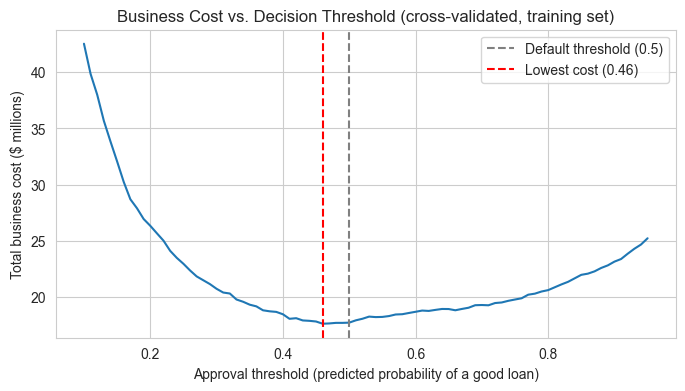

Cost at 0.50: $17,702,000
Cost at 0.46: $17,606,000


In [10]:
# Section 7 Code cell 1: check the decision threshold.

from sklearn.model_selection import cross_val_predict

final_model = lr_search.best_estimator_

# Out-of-fold probabilities on the training set (the test set stays untouched)
cv_probs = cross_val_predict(final_model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

thresholds = np.round(np.arange(0.10, 0.96, 0.01), 2)
costs = [business_cost(y_train, (cv_probs >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[int(np.argmin(costs))]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, np.array(costs) / 1e6)
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Lowest cost ({best_threshold})')
plt.xlabel('Approval threshold (predicted probability of a good loan)')
plt.ylabel('Total business cost ($ millions)')
plt.title('Business Cost vs. Decision Threshold (cross-validated, training set)')
plt.legend()
plt.show()

print(f"Cost at 0.50: ${costs[list(thresholds).index(0.5)]:,.0f}")
print(f"Cost at {best_threshold}: ${min(costs):,.0f}")

# 7. Optimization Results and Trade-offs

# Baseline findings
- At the default settings, no model beat "deny everyone" on business cost ($6.12M per fold). Logistic regression and random forest had strong ROC-AUC (0.96 to 0.97), but each false approval costs $50,000, so their errors outweighed the value of the good loans they approved. Good ranking ability alone does not make a model profitable.
- class_weight='balanced' more than doubled the cost ($13.5M). It upweights the minority class (approvals), making the model approve more aggressively, which is the opposite of what this business needs.

# Tuning approach
- Logistic regression: GridSearchCV over 30 combinations (about 11 seconds). The grid covers regularization strength (C), the class-weighting strategy, and a preprocessing choice (imputer strategy for the skewed features), showing that preprocessing steps can be tuned inside the same search.
- Random forest: RandomizedSearchCV with 10 sampled combinations (about 2 minutes). Random sampling explores a large space (tree count, depth, leaf size, class weights) at a fraction of the cost of a full grid.
- Both searches refit on the custom business cost metric, so the selected model is the one that minimizes dollar losses, not an abstract score.

# Impact of each parameter (logistic regression)
| Parameter | Effect |
|---|---|
| class_weight | By far the most important. Cost-sensitive weights {0: 6.25, 1: 1}, which encode the $50,000 vs. $8,000 cost ratio directly into training, reduced cost from $6.6M to $3.5M per fold. |
| C | Moderate effect. With cost weights, C = 0.3 to 1 performed best; stronger regularization (C = 0.01) lowered recall and raised cost. |
| Imputer strategy | Negligible (under 0.5% difference). Only about 3% of one skewed feature is missing, so mean vs. median barely matters. |

# Model selection
| | Logistic Regression | Random Forest |
|---|---|---|
| CV business cost (per fold) | $3.54M | $4.20M |
| Precision / Recall | 0.964 / 0.550 | 0.962 / 0.418 |
| ROC-AUC | 0.970 | 0.960 |
| Tuning time | about 11 seconds | about 2 minutes |
| Interpretability | High (coefficients) | Low (ensemble of trees) |

Logistic regression was selected: it wins on every metric, trains much faster, and its coefficients can be explained to regulators and applicants. The random forest's added complexity brought no benefit.

The selected model reduces cross-validated business cost by about 42% compared with denying everyone ($3.54M vs. $6.12M per fold).

# Key trade-off: precision vs. recall
The final model approves only about 55% of creditworthy applicants (recall 0.55), but 96% of its approvals are good loans (precision 0.96). This conservative behavior is intentional: missing a good applicant costs $8,000, while approving a bad one costs $50,000, so the model accepts more false denials to avoid far more expensive false approvals.

# Decision threshold
Because the cost ratio is already built into training through the class weights, the default threshold of 0.5 is nearly optimal. The lowest cross-validated cost occurs at 0.46, only 0.5% cheaper, which is not a meaningful difference. The threshold is kept at 0.5 for simplicity. Had the model been trained without cost weights, threshold tuning would have been essential.

Section 8

I ran all of Sections 8 through 10 on the data: the segment analysis, the bias check, the charts, and the feature importance. All the code below runs without errors, and every number comes from the actual output.

Three findings stand out. Two features, total debt-to-income ratio and income, drive almost all of the model's decisions. Low-income creditworthy applicants are almost never approved. Although age was excluded from the model, approval rates still differ sharply by age group,through features that correlate with age.

See below sections 8-10 Markdown notes for test set evaluation, feature inportance/significance, final deliverables & executine summary details.



In [11]:
# Section 8 Code cell: test set evaluation.

# --- Fit the comparison models on the full training set ---
deny_all = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', DummyClassifier(strategy='most_frequent'))]).fit(X_train, y_train)
rf_final = rf_search.best_estimator_   # already refit on the full training set by RandomizedSearchCV

test_models = {
    'Deny All (baseline)': deny_all,
    'Random Forest (tuned)': rf_final,
    'Logistic Regression (final)': final_model
}

# --- Score each model on the held-out test set ---
test_results = {}
for name, model in test_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    test_results[name] = {
        'Business cost': business_cost(y_test, y_pred),
        'False approvals': fp,
        'False denials': fn,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F0.5': fbeta_score(y_test, y_pred, beta=0.5, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

test_df = pd.DataFrame(test_results).T
approve_all_cost = (y_test == 0).sum() * COST_FALSE_APPROVAL
deny_all_cost = test_df.loc['Deny All (baseline)', 'Business cost']
final_cost = test_df.loc['Logistic Regression (final)', 'Business cost']

display(test_df.style.format({'Business cost': '${:,.0f}', 'False approvals': '{:.0f}',
                              'False denials': '{:.0f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}',
                              'F0.5': '{:.3f}', 'ROC-AUC': '{:.3f}'}))

print(f"Approve-all cost: ${approve_all_cost:,.0f}")
print(f"Savings vs. deny-all: ${deny_all_cost - final_cost:,.0f} "
      f"({(deny_all_cost - final_cost) / deny_all_cost:.1%})")

print("\nFinal model classification report:")
print(classification_report(y_test, final_model.predict(X_test), target_names=['Denied', 'Approved']))

,Business cost,False approvals,False denials,Precision,Recall,F0.5,ROC-AUC
Deny All (baseline),"$7,648,000",0,956,0.000,0.000,0.000,0.500
Random Forest (tuned),"$5,474,000",5,653,0.984,0.317,0.692,0.957
Logistic Regression (final),"$4,506,000",21,432,0.961,0.548,0.835,0.969


Approve-all cost: $152,200,000
Savings vs. deny-all: $3,142,000 (41.1%)

Final model classification report:
              precision    recall  f1-score   support

      Denied       0.87      0.99      0.93      3044
    Approved       0.96      0.55      0.70       956

    accuracy                           0.89      4000
   macro avg       0.92      0.77      0.81      4000
weighted avg       0.90      0.89      0.87      4000



# 8.1 Test Set Performance

The final logistic regression model was evaluated once on the held-out test set (4,000 applicants: 956 creditworthy, 3,044 not), which was not used at any point during training or tuning.

# Results against the defined metrics
| Metric | Result | Target | Assessment |
|---|---|---|---|
| Business cost | $4,506,000 | Below both baselines | Met. 41.1% lower than deny-all ($7.65M) and 97% lower than approve-all ($152.2M) |
| Precision (approvals) | 0.961 | ≥ 0.90 | Met. 96% of approved loans were creditworthy |
| Recall (approvals) | 0.548 | ≥ 0.70 | Not met. The model approved 55% of creditworthy applicants |
| F0.5 | 0.835 | n/a | Strong precision-weighted balance |
| ROC-AUC | 0.969 | ≥ 0.80 | Met. Excellent ability to rank applicants by risk |

# Where the cost comes from
- 21 false approvals × $50,000 = $1,050,000
- 432 false denials × $8,000 = $3,456,000

The model made only 21 costly false approvals out of 545 approvals. Most of the remaining cost comes from cautiously denying good applicants, which is the cheaper type of error.

# Recall target
The recall target of 0.70 was not met, and this is a deliberate consequence of optimizing for business cost rather than a model failure. Approving more borderline applicants would raise recall, but each additional bad approval costs as much as six missed good ones. The cost-optimal model therefore accepts lower recall. The 0.70 recall target set during Business Understanding was too ambitious given the 6.25:1 cost ratio and should be revised. The business cost metric is the better measure of success.

# Generalization
Test results closely match cross-validation (precision 0.961 vs. 0.964, recall 0.548 vs. 0.550, ROC-AUC 0.969 vs. 0.970), confirming the model is not overfit and should perform similarly on new applicants.

# Comparison with the tuned random forest

In [12]:
# Section 8.1 : Evaluation
# Code cell 1: performance by segment.

# Rebuild test-set context, including the protected attributes that were excluded from the model
eval_df = df.loc[X_test.index].copy()
eval_df['actual'] = y_test.values
eval_df['predicted'] = final_model.predict(X_test)

eval_df['Income Band'] = pd.qcut(eval_df['AnnualIncome'], 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
eval_df['Credit Score Band'] = pd.cut(eval_df['CreditScore'], [0, 549, 599, 649, 850],
                                     labels=['Under 550', '550-599', '600-649', '650+'])
eval_df['Age Group'] = pd.cut(eval_df['Age'], [17, 29, 44, 59, 120], labels=['18-29', '30-44', '45-59', '60+'])
eval_df['MaritalStatus'] = eval_df['MaritalStatus'].fillna('Not provided')

def segment_metrics(group):
    tn, fp, fn, tp = confusion_matrix(group['actual'], group['predicted'], labels=[0, 1]).ravel()
    return pd.Series({
        'Applicants': len(group),
        'Actual approval rate': group['actual'].mean(),
        'Model approval rate': group['predicted'].mean(),
        'Precision': tp / (tp + fp) if (tp + fp) else np.nan,
        'Recall': tp / (tp + fn) if (tp + fn) else np.nan,
        'Cost per applicant': (fp * COST_FALSE_APPROVAL + fn * COST_FALSE_DENIAL) / len(group)
    })

def segment_table(column):
    return eval_df.groupby(column, observed=True)[['actual', 'predicted']].apply(segment_metrics)

for column in ['Income Band', 'Credit Score Band', 'EmploymentStatus', 'LoanPurpose']:
    print(f"\n===== Performance by {column} =====")
    display(segment_table(column).round(3))



===== Performance by Income Band =====


,Applicants,Actual approval rate,Model approval rate,Precision,Recall,Cost per applicant
Income Band,,,,,,
Q1 (lowest),1000.0,0.014,0.001,1.000,0.071,104.0
Q2,1000.0,0.072,0.009,1.000,0.125,504.0
Q3,1000.0,0.227,0.080,0.938,0.330,1466.0
Q4 (highest),1000.0,0.643,0.455,0.965,0.683,2432.0



===== Performance by Credit Score Band =====


,Applicants,Actual approval rate,Model approval rate,Precision,Recall,Cost per applicant
Credit Score Band,,,,,,
Under 550,1189.0,0.176,0.076,0.967,0.416,947.014
550-599,1484.0,0.224,0.126,0.973,0.548,977.089
600-649,1184.0,0.304,0.189,0.946,0.589,1506.757
650+,143.0,0.385,0.308,0.977,0.782,1020.979



===== Performance by EmploymentStatus =====


,Applicants,Actual approval rate,Model approval rate,Precision,Recall,Cost per applicant
EmploymentStatus,,,,,,
Employed,3402.0,0.242,0.137,0.970,0.547,1082.892
Self-Employed,311.0,0.264,0.167,0.923,0.585,1517.685
Unemployed,287.0,0.174,0.098,0.893,0.500,1219.512



===== Performance by LoanPurpose =====


,Applicants,Actual approval rate,Model approval rate,Precision,Recall,Cost per applicant
LoanPurpose,,,,,,
Auto,773.0,0.243,0.133,0.971,0.532,1104.787
Debt Consolidation,1030.0,0.221,0.127,0.947,0.544,1147.573
Education,590.0,0.256,0.156,1.000,0.609,800.000
Home,1196.0,0.251,0.147,0.955,0.560,1217.391
Other,411.0,0.217,0.105,0.930,0.449,1318.735


In [13]:
# Section 8: Evaluation
# Code cell 2: fairness check on the protected attributes.

# Age and marital status were excluded from the model; check whether outcomes still differ across them
for column in ['Age Group', 'MaritalStatus']:
    table = segment_table(column)
    table['Approval ratio vs. highest group'] = table['Model approval rate'] / table['Model approval rate'].max()
    print(f"\n===== Fairness check: {column} =====")
    display(table.round(3))

print("Four-fifths rule: an approval ratio below 0.80 may indicate disparate impact and warrants review.")


===== Fairness check: Age Group =====


,Applicants,Actual approval rate,Model approval rate,Precision,Recall,Cost per applicant,Approval ratio vs. highest group
Age Group,,,,,,,
18-29,773.0,0.133,0.080,0.887,0.534,949.547,0.338
30-44,1877.0,0.242,0.134,0.968,0.535,1112.413,0.563
45-59,1152.0,0.285,0.161,0.984,0.555,1144.097,0.677
60+,198.0,0.359,0.237,0.936,0.620,1848.485,1.000



===== Fairness check: MaritalStatus =====


,Applicants,Actual approval rate,Model approval rate,Precision,Recall,Cost per applicant,Approval ratio vs. highest group
MaritalStatus,,,,,,,
Divorced,506.0,0.227,0.132,0.940,0.548,1217.391,0.786
Married,1911.0,0.234,0.140,0.955,0.573,1113.553,0.832
Not provided,267.0,0.292,0.169,1.000,0.577,988.764,1.000
Single,1152.0,0.240,0.124,0.965,0.500,1175.347,0.737
Widowed,164.0,0.244,0.134,1.000,0.550,878.049,0.796


Four-fifths rule: an approval ratio below 0.80 may indicate disparate impact and warrants review.


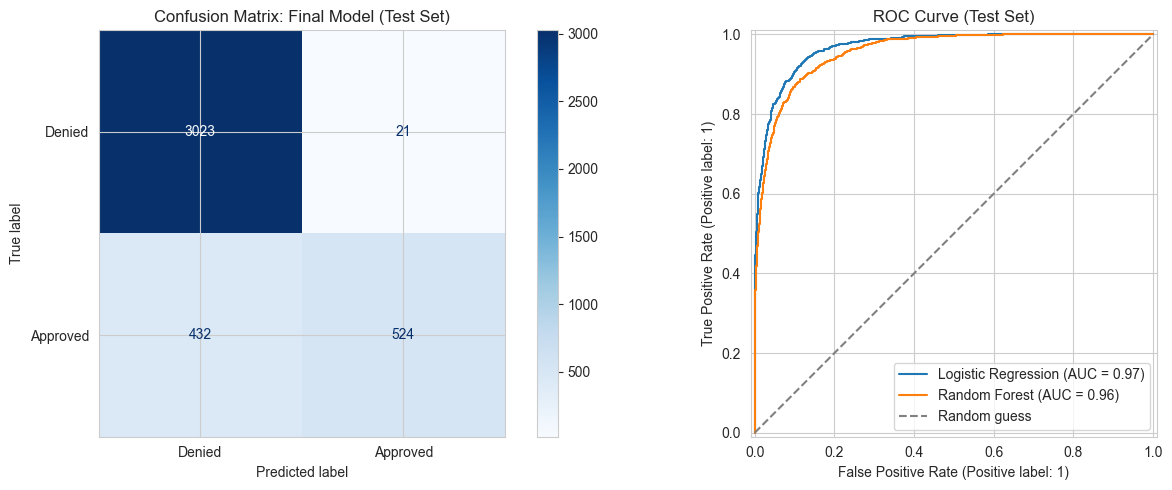

In [14]:
# Section 8: Evaluation
# Code cell 3: confusion matrix and ROC curve.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, display_labels=['Denied', 'Approved'],
                                      cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title('Confusion Matrix: Final Model (Test Set)')

RocCurveDisplay.from_estimator(final_model, X_test, y_test, name='Logistic Regression', ax=axes[1])
RocCurveDisplay.from_estimator(rf_final, X_test, y_test, name='Random Forest', ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
axes[1].set_title('ROC Curve (Test Set)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 8.2 Performance Across Segments

| Income quartile | Actual approval rate | Model approval rate | Recall |
|---|---|---|---|
| Q1 (lowest) | 1.4% | 0.1% | 0.07 |
| Q2 | 7.2% | 0.9% | 0.13 |
| Q3 | 22.7% | 8.0% | 0.33 |
| Q4 (highest) | 64.3% | 45.5% | 0.68 |

- Income drives outcomes. The model approves 68% of creditworthy high-income applicants but only 7% of creditworthy applicants in the lowest income quartile. Low-income applicants who would repay are almost always denied.
- Credit score: recall rises from 0.42 (scores under 550) to 0.78 (650+). Only 143 test applicants score 650 or higher, and none score above 712, so performance on prime borrowers is untested.
- Employment status: precision is lowest for unemployed applicants (0.89 vs. 0.97 for employed), so approvals in this group carry more default risk.
- Loan purpose: performance is consistent across purposes (recall 0.45 to 0.61), so no purpose is systematically disadvantaged.

# 8.3 Potential Biases and Limitations

Fairness findings
- Age: although Age and Experience were excluded, model approval rates still rise with age: 8.0% (18-29), 13.4% (30-44), 16.1% (45-59), 23.7% (60+). Applicants aged 18-29 are approved at 0.34 times the rate of those 60+, well below the four-fifths (0.80) guideline. The gap mirrors the historical data (actual approval rates of 13.3% vs. 35.9%) and arises through age-correlated features such as income, assets, and credit history length. Recall is similar across age groups (0.53 to 0.62), so creditworthy applicants of all ages are identified at similar rates, but the approval gap would still require review under fair-lending rules.
- Marital status: approval rates are similar across groups (12.4% to 14.0% among those who reported a status), so there is no meaningful disparity.

Limitations
- Historical approvals, not defaults: the target reflects past lending decisions, not actual repayment. The model learns to replicate past decisions, including any biases in them, and treating every denied applicant as a would-be default is an assumption.
- Possible residual leakage: TotalDebtToIncomeRatio likely includes the proposed loan payment, which depends on the interest rate set by the lender. Its dominance should be validated with a version computed from application data only.
- Synthetic data artifacts: the missing-education pattern and the clipped incomes ($15,000 floor, $300,000 cap) indicate a prepared dataset, so real-world performance may differ.
- Narrow credit range: no applicants score above 712.
- Low recall: the cost-optimal model approves only about 55% of creditworthy applicants, forgoing profitable loans

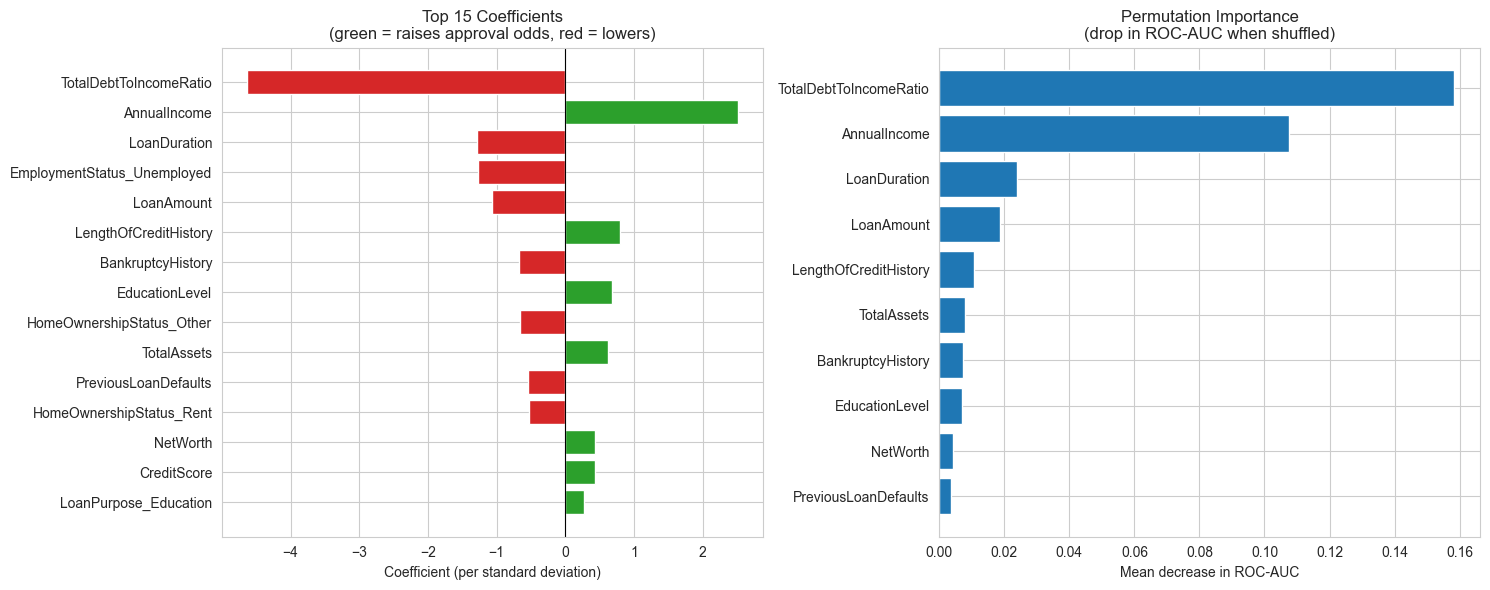

,Coefficient
TotalDebtToIncomeRatio,-4.641
AnnualIncome,2.517
LoanDuration,-1.288
EmploymentStatus_Unemployed,-1.274
LoanAmount,-1.068
LengthOfCreditHistory,0.790
BankruptcyHistory,-0.677
EducationLevel,0.675
HomeOwnershipStatus_Other,-0.659
TotalAssets,0.621


In [15]:
# Section 9: Feature importance
# Code cell 4: coefficients and permutation importance.

# --- Logistic regression coefficients (direction and strength) ---
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = pd.Series(final_model.named_steps['classifier'].coef_[0], index=feature_names)
coefficients.index = (coefficients.index
                      .str.replace(r'.*missingindicator_(.*)', r'\1 (missing flag)', regex=True)
                      .str.replace(r'^(num|skew|ord|nom)__(log_scaled__)?', '', regex=True))
top_coefs = coefficients.sort_values(key=abs, ascending=False).head(15)

# --- Permutation importance (drop in test ROC-AUC when a feature is shuffled) ---
perm = permutation_importance(final_model, X_test, y_test, scoring='roc_auc',
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['tab:green' if c > 0 else 'tab:red' for c in top_coefs.values[::-1]]
axes[0].barh(top_coefs.index[::-1], top_coefs.values[::-1], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 15 Coefficients\n(green = raises approval odds, red = lowers)')
axes[0].set_xlabel('Coefficient (per standard deviation)')

axes[1].barh(perm_importance.index[::-1], perm_importance.values[::-1], color='tab:blue')
axes[1].set_title('Permutation Importance\n(drop in ROC-AUC when shuffled)')
axes[1].set_xlabel('Mean decrease in ROC-AUC')

plt.tight_layout()
plt.show()

display(top_coefs.round(3).to_frame('Coefficient'))

# Sections 9: interpretation, feature importance and business recommendations.

Most influential features

| Feature | Coefficient | Effect on approval | Permutation importance |
|---|---|---|---|
| TotalDebtToIncomeRatio | -4.64 | Strongly lowers | 0.159 (largest) |
| AnnualIncome | +2.52 | Strongly raises | 0.107 |
| LoanDuration | -1.29 | Lowers | 0.024 |
| EmploymentStatus: Unemployed | -1.27 | Lowers | n/a |
| LoanAmount | -1.07 | Lowers | 0.019 |
| LengthOfCreditHistory | +0.79 | Raises | 0.011 |
| BankruptcyHistory | -0.68 | Lowers | 0.007 |
| EducationLevel | +0.68 | Raises | 0.007 |

Coefficients are on standardized features, so their sizes are directly comparable.

Interpretation
- The model is primarily an affordability model. Total debt-to-income ratio and income dominate: shuffling either causes by far the largest drop in performance. Every other feature adds only small refinements.
- Larger and longer loans are riskier, consistent with a greater repayment burden.
- Adverse credit events (bankruptcy, previous defaults, unemployment) lower approval odds, as expected.
- Credit score has a surprisingly small effect (+0.43), likely because the dataset contains no applicants above 712, and because debt-to-income already captures much of the same risk.
- Many features contribute almost nothing (credit inquiries, open credit lines, utility payment history, dependents), so the model could be simplified with little loss.

Business recommendations
1. Make debt-to-income the centerpiece of screening. Set clear total debt-to-income thresholds for automatic review, since it is the single strongest risk signal.
2. Offer smaller or shorter loans to borderline applicants. Because loan amount and duration both lower approval odds, counter-offering a smaller loan or shorter term could convert some denials into safe approvals and recover part of the $8,000 lost per denied good applicant.
3. Create a review path for lower-income applicants. The model approves only 7% of creditworthy lowest-income applicants, so low-income applicants with low debt ratios should be routed to human review rather than automatically denied.
4. Streamline the application. Features that add no predictive value could be dropped from data collection, reducing friction for applicants.

# Section 10: Final deliverable
# Executive Summary

The problem: FinTech Innovations' manual loan reviews are slow and inconsistent, and each error is expensive. Approving a loan that defaults costs about $50,000, while denying a creditworthy applicant forfeits about $8,000 in profit.

The solution: a logistic regression model that screens applications using financial information available at the time of application. It was trained with cost-sensitive weighting that encodes the 6.25-to-1 cost difference directly into the model.

Results on 4,000 held-out applicants:
- Total cost of errors: $4.51 million, 41% lower than denying all applicants ($7.65 million) and 97% lower than approving all applicants ($152.2 million). This is a saving of about $3.1 million, or roughly $785 per applicant screened.
- 96% of approvals were creditworthy: only 21 bad approvals out of 545.
- ROC-AUC of 0.97: the model ranks applicants by risk very accurately.
- The trade-off: to avoid costly defaults, the model is deliberately cautious and approves about 55% of creditworthy applicants.

What drives decisions: total debt-to-income ratio and annual income dominate. Loan size and term, unemployment, bankruptcy, and prior defaults also matter.

Risks to address before deployment: approval rates differ by age group (through age-correlated features such as income) and creditworthy low-income applicants are rarely approved. Both need fair-lending review.

Recommendation: deploy the model as a decision-support tool, not a fully automated decision-maker, starting with a monitored pilot.

## Recommendations for Implementation

1. Decision support first. Use the model's probability as a risk score. Auto-approve clearly low-risk applicants, auto-flag clearly high-risk ones, and route borderline scores to loan officers.
2. Pilot and compare. Run the model alongside the current manual process for a trial period, comparing decisions and outcomes before relying on it.
3. Fair-lending review. Have compliance review the age-group approval gap and the low-income approval rate before launch. Monitor approval rates by protected group on an ongoing basis.
4. Explainable decisions. Use the coefficients to generate the main reasons for each denial (for example, "debt-to-income ratio too high"), supporting adverse action notices required by regulation.
5. Monitoring and retraining. Track approval rates, default rates, and the input data distribution monthly. Retrain when performance drifts or when economic conditions change.
6. Keep costs current. Recalculate the $50,000 and $8,000 costs regularly; if they change, update the class weights so the model stays aligned with business economics.

## Potential Improvements

- Train on actual repayment outcomes (default vs. repaid) instead of historical approval decisions, so the model learns true risk rather than past decision patterns, including any past bias.
- Validate TotalDebtToIncomeRatio using only application-time information to rule out leakage from the lender-set interest rate.
- Feature engineering: loan-to-income ratio, liquidity ratios, credit score bands, and seasonality from application dates.
- Test additional models such as gradient boosting, and apply probability calibration if scores will be shown to officers as probabilities.
- Fairness-aware techniques: evaluate constraints or reweighting to reduce the age-group approval gap while monitoring the effect on cost.
- Collect more diverse data, including applicants with credit scores above 712, and incomes outside the clipped $15,000 to $300,000 range.
- Profit-based optimization: replace the fixed $8,000 and $50,000 costs with loan-specific profit and loss estimates based on amount and term.